# 4. Random Forest

Same feature-availability comparison as notebook 3, using Random Forest instead of Logistic Regression, plus feature importance from the full-data fit.

In [1]:
import sys
from pathlib import Path

# Find the project root regardless of what VS Code / Jupyter set as the
# working directory (VS Code defaults notebooks to the workspace root,
# not the notebook's own folder, so ".." alone isn't reliable).
cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.evaluate import evaluate_feature_set
from src.models import get_random_forest
from src.preprocessing import get_feature_availability_sets, load_data

sns.set_theme(style="whitegrid")
df = load_data()
feature_sets = get_feature_availability_sets(df)


## 4.1 Random Forest across all three feature sets

In [2]:
rf_feature_results = []
rf_full_pipe = None  # keep the fitted Full-Data pipeline for feature importance below

for name, cols in feature_sets.items():
    if name == "Full Data":
        # also keep the fitted pipeline + test split for feature importance
        # and for the cross-model comparison in 05_model_comparison.ipynb
        result, rf_full_pipe, X_test_rf, y_test_rf, y_pred_rf = evaluate_feature_set(
            df, cols, name, get_random_forest(), scale_numeric=False, return_split=True
        )
    else:
        result = evaluate_feature_set(df, cols, name, get_random_forest(), scale_numeric=False)
    rf_feature_results.append(result)

rf_feature_results_df = pd.DataFrame(rf_feature_results)
display(rf_feature_results_df.round(3))

# Save so 05_model_comparison.ipynb can load it without recomputing
rf_feature_results_df.to_csv("../data/processed/rf_feature_availability.csv", index=False)


,Feature Set,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,Day 1,0.612,0.539,0.627,0.258,0.731
1,After Semester 1,0.716,0.647,0.697,0.390,0.846
2,Full Data,0.763,0.713,0.718,0.547,0.869


## 4.2 Visualization
### 4.2.1 Macro F1 and accuracy

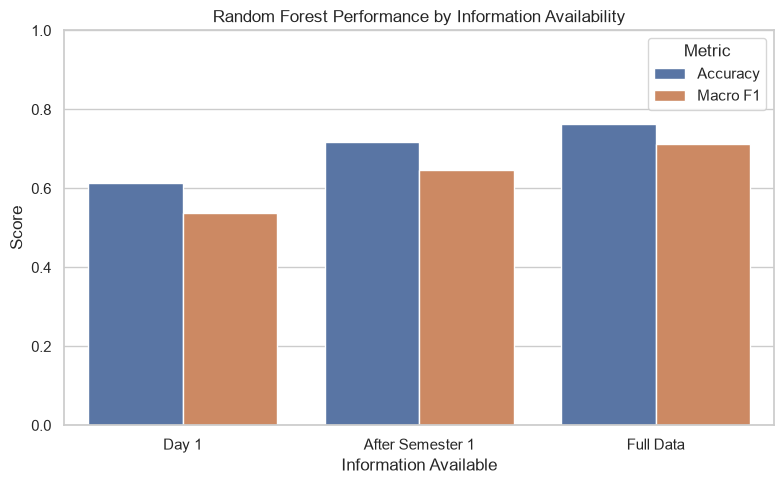

In [3]:
rf_performance_long = rf_feature_results_df.melt(
    id_vars="Feature Set", value_vars=["Accuracy", "Macro F1"],
    var_name="Metric", value_name="Score"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rf_performance_long, x="Feature Set", y="Score", hue="Metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Random Forest Performance by Information Availability")
ax.set_xlabel("Information Available")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()


### 4.2.2 Per-class recall

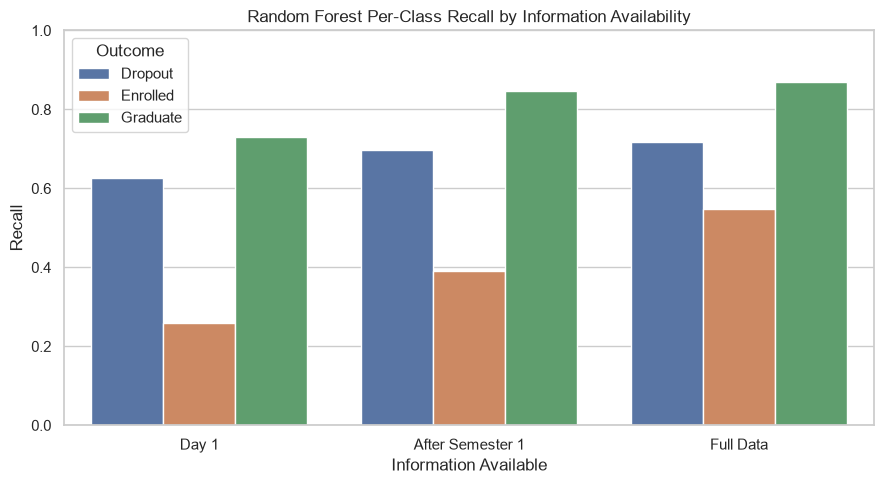

In [4]:
rf_recall_long = rf_feature_results_df.melt(
    id_vars="Feature Set",
    value_vars=["Dropout Recall", "Enrolled Recall", "Graduate Recall"],
    var_name="Outcome", value_name="Recall"
)
rf_recall_long["Outcome"] = rf_recall_long["Outcome"].str.replace(" Recall", "", regex=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=rf_recall_long, x="Feature Set", y="Recall", hue="Outcome", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Random Forest Per-Class Recall by Information Availability")
ax.set_xlabel("Information Available")
ax.set_ylabel("Recall")
plt.tight_layout()
plt.show()


## 4.3 Random Forest feature importance

Using the fitted Full-Data pipeline from section 4.1.

In [5]:
rf_preprocessor = rf_full_pipe.named_steps["preprocess"]
rf_model = rf_full_pipe.named_steps["model"]

rf_feature_names = rf_preprocessor.get_feature_names_out()

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.feature_importances_
})

rf_importance_df["Feature"] = (
    rf_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("bin__", "", regex=False)
)

rf_importance_df = rf_importance_df.sort_values("Importance", ascending=False).reset_index(drop=True)
display(rf_importance_df.head(20))


,Feature,Importance
0,Curricular units 2nd sem (approved),0.088520
1,Curricular units 2nd sem (grade),0.078604
2,Curricular units 1st sem (approved),0.065846
3,Curricular units 1st sem (grade),0.061813
4,Curricular units 2nd sem (evaluations),0.039465
5,Admission grade,0.038510
6,Curricular units 1st sem (evaluations),0.038104
7,Age at enrollment,0.036058
8,Previous qualification (grade),0.034789
9,Tuition fees up to date,0.031044


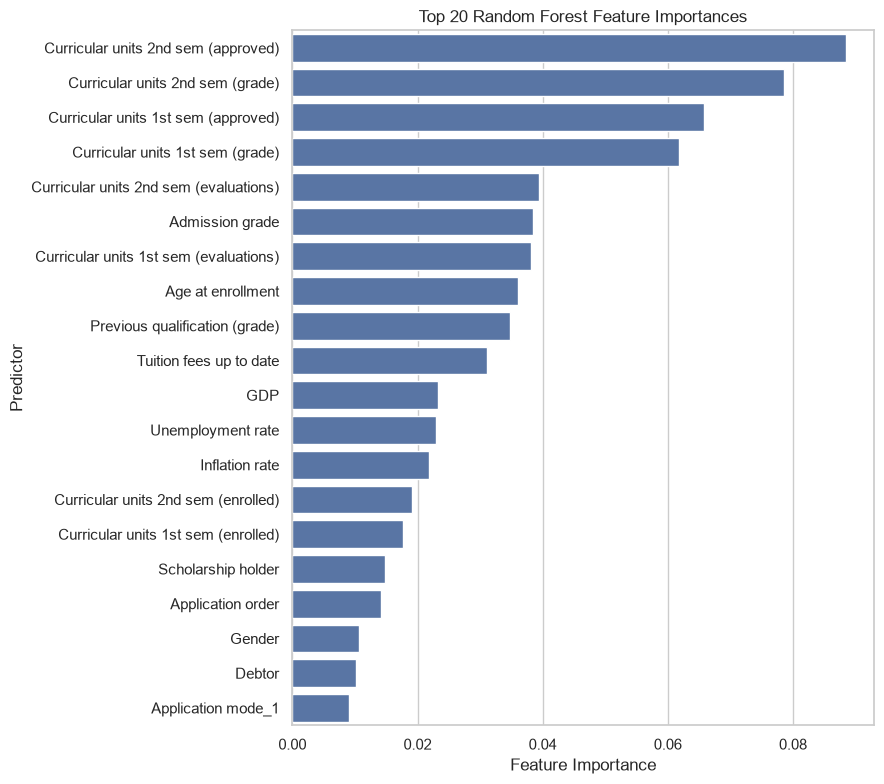

In [6]:
top_rf_features = rf_importance_df.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=top_rf_features, x="Importance", y="Feature", ax=ax)
ax.set_title("Top 20 Random Forest Feature Importances")
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Predictor")
plt.tight_layout()
plt.show()


According to the fitted Random Forest, these variables contributed most strongly to the model's tree splits.